In [1]:
import numpy as np
import scipy
import scipy.sparse as sp
import time
import matplotlib.pyplot as plt

from scipy.optimize import linprog
from scipy.sparse.linalg import factorized

print("NumPy version:", np.__version__)
print("SciPy version:", scipy.__version__)

NumPy version: 2.4.3
SciPy version: 1.17.1


In [2]:
from optimization_model import OptimizationModel, OptimizationResult

print("OptimizationModel imported successfully.")
print("OptimizationResult imported successfully.")

OptimizationModel imported successfully.
OptimizationResult imported successfully.


In [3]:
def constraint_violation(Ax, lower, upper):
    """
    Maximum violation of constraint bounds.

    Constraints are represented as:

        lower <= A*x <= upper
    """

    lower_violation = np.maximum(lower - Ax, 0.0)
    upper_violation = np.maximum(Ax - upper, 0.0)

    max_lower = np.max(lower_violation)
    max_upper = np.max(upper_violation)

    return float(max(max_lower, max_upper))


def bound_violation(x, lower, upper):
    """
    Maximum violation of variable bounds.
    """

    lower_violation = np.maximum(lower - x, 0.0)
    upper_violation = np.maximum(x - upper, 0.0)

    max_lower = np.max(lower_violation)
    max_upper = np.max(upper_violation)

    return float(max(max_lower, max_upper))


def integrality_violation(x, integrality):
    """
    Maximum distance of integer variables from nearest integer.
    """

    integer_mask = integrality != 0

    if not np.any(integer_mask):
        return 0.0

    return float(
        np.max(
            np.abs(
                x[integer_mask] -
                np.round(x[integer_mask])
            )
        )
    )


def check_solution(model, x):
    """
    Check a solution against a generic OptimizationModel.
    """

    Ax = model.A @ x

    constraint_error = constraint_violation(
        Ax,
        model.constraint_lower,
        model.constraint_upper
    )

    bound_error = bound_violation(
        x,
        model.variable_lower,
        model.variable_upper
    )

    integer_error = integrality_violation(
        x,
        model.variable_integrality
    )

    objective = model.objective @ x

    return {
        "objective": float(objective),
        "constraint_violation": constraint_error,
        "bound_violation": bound_error,
        "integrality_violation": integer_error
    }

In [4]:
A_test = sp.csr_matrix([
    [1.0, 1.0],
    [2.0, 1.0]
])

c_test = np.array([
    3.0,
    2.0
])

constraint_lower_test = np.array([
    1.0,
    -np.inf
])

constraint_upper_test = np.array([
    np.inf,
    4.0
])

variable_lower_test = np.array([
    0.0,
    0.0
])

variable_upper_test = np.array([
    10.0,
    10.0
])

variable_integrality_test = np.array([
    0,
    0
])

print("Matrix shape:", A_test.shape)
print("Number of nonzeros:", A_test.nnz)
print("Objective:", c_test)

Matrix shape: (2, 2)
Number of nonzeros: 4
Objective: [3. 2.]


In [5]:
model = OptimizationModel(
    A=A_test,
    constraint_lower=constraint_lower_test,
    constraint_upper=constraint_upper_test,
    objective=c_test,
    variable_lower=variable_lower_test,
    variable_upper=variable_upper_test,
    variable_integrality=variable_integrality_test,
    objective_sense="min"
)

print("OptimizationModel created successfully.")
print()
print("Model summary:")
print(model.summary())

OptimizationModel created successfully.

Model summary:
{'problem_type': 'LP', 'variables': 2, 'constraints': 2, 'nonzeros': 4, 'integer_variables': 0, 'continuous_variables': 2, 'objective_sense': 'min'}


In [6]:
print("Problem type:", model.problem_type)
print("Number of variables:", model.n_variables)
print("Number of constraints:", model.n_constraints)
print("Number of nonzeros:", model.nnz)
print("Integer variables:", model.n_integer_variables)
print("Continuous variables:", model.n_continuous_variables)
print("Objective sense:", model.objective_sense)

Problem type: LP
Number of variables: 2
Number of constraints: 2
Number of nonzeros: 4
Integer variables: 0
Continuous variables: 2
Objective sense: min


In [7]:
print("Problem type:", model.problem_type)
print("Number of variables:", model.n_variables)
print("Number of constraints:", model.n_constraints)
print("Number of nonzeros:", model.nnz)
print("Integer variables:", model.n_integer_variables)
print("Continuous variables:", model.n_continuous_variables)
print("Objective sense:", model.objective_sense)

Problem type: LP
Number of variables: 2
Number of constraints: 2
Number of nonzeros: 4
Integer variables: 0
Continuous variables: 2
Objective sense: min


In [8]:
from scipy.optimize import linprog

highs_result = linprog(
    c=model.objective,
    A_ub=np.array(
        [
            [-1.0, -1.0],  # x1 + x2 >= 1
            [2.0, 1.0],  # 2x1 + x2 <= 4
        ]
    ),
    b_ub=np.array([-1.0, 4.0]),
    bounds=[(0, 10), (0, 10)],
    method="highs",
)

print("HiGHS status:")
print(highs_result.message)

print()
print("HiGHS solution:")
print(highs_result.x)

print()
print("HiGHS objective:")
print(highs_result.fun)

HiGHS status:
Optimization terminated successfully. (HiGHS Status 7: Optimal)

HiGHS solution:
[0. 1.]

HiGHS objective:
2.0


In [9]:
class ADMMSolver:

    def __init__(
        self,
        rho=1.0,
        max_iterations=1000,
        tolerance=1e-6,
        backend="CPU"
    ):
        self.rho = float(rho)
        self.max_iterations = int(max_iterations)
        self.tolerance = float(tolerance)
        self.backend = backend

        # History for analysis and plotting
        self.objective_history_ = []
        self.constraint_violation_history_ = []
        self.primal_residual_history_ = []
        self.dual_residual_history_ = []

    def _validate_model(self, model):

        if model.problem_type != "LP":
            raise ValueError(
                "ADMMSolver currently supports LP models only. "
                "MILP solving is not implemented."
            )

        if model.A.shape[0] != len(model.constraint_lower):
            raise ValueError(
                "Constraint lower bounds do not match A."
            )

        if model.A.shape[0] != len(model.constraint_upper):
            raise ValueError(
                "Constraint upper bounds do not match A."
            )

        if model.A.shape[1] != len(model.objective):
            raise ValueError(
                "Objective length does not match A."
            )

    def solve(self, model):

        self._validate_model(model)

        A = model.A
        objective = model.objective

        constraint_lower = model.constraint_lower
        constraint_upper = model.constraint_upper

        variable_lower = model.variable_lower
        variable_upper = model.variable_upper

        n = model.n_variables
        m = model.n_constraints

        # Reset history
        self.objective_history_ = []
        self.constraint_violation_history_ = []
        self.primal_residual_history_ = []
        self.dual_residual_history_ = []

        # --------------------------------------------------
        # Objective handling
        # --------------------------------------------------
        #
        # ADMM internally works with minimization.
        #
        # For a MAX problem:
        #
        #       maximize c*x
        #
        # becomes:
        #
        #       minimize -c*x
        #
        # The final reported objective is still model.objective @ x.
        # --------------------------------------------------

        if model.objective_sense == "min":
            c = objective.copy()
        else:
            c = -objective.copy()

        # --------------------------------------------------
        # Initial values
        # --------------------------------------------------

        x = np.zeros(n)

        # Make initial x satisfy variable bounds
        x = np.clip(
            x,
            variable_lower,
            variable_upper
        )

        Ax = A @ x

        # z is the projection of Ax onto
        #
        # constraint_lower <= z <= constraint_upper
        #
        z = np.minimum(
            np.maximum(
                Ax,
                constraint_lower
            ),
            constraint_upper
        )

        # Scaled dual variable
        u = np.zeros(m)

        # --------------------------------------------------
        # Matrix for x-update
        # --------------------------------------------------
        #
        # This is suitable for SMALL sparse LP tests.
        #
        # DO NOT construct A.T @ A for the
        # 472,798-variable airline model.
        # --------------------------------------------------

        ATA = A.T @ A

        M = (
            sp.eye(n, format="csc")
            + self.rho * ATA.tocsc()
        )

        solve_M = factorized(M)

        start_time = time.perf_counter()

        status = "MAX_ITERATIONS_REACHED"

        final_constraint_violation = np.inf
        final_bound_violation = np.inf

        # --------------------------------------------------
        # ADMM iterations
        # --------------------------------------------------

        for iteration in range(1, self.max_iterations + 1):

            # Save previous z for dual residual
            z_previous = z.copy()

            # --------------------------------------------------
            # x-update
            # --------------------------------------------------

            rhs = (
                -c
                + self.rho * A.T @ (z - u)
            )

            x = solve_M(rhs)

            # Apply variable bounds
            x = np.clip(
                x,
                variable_lower,
                variable_upper
            )

            # --------------------------------------------------
            # Calculate Ax
            # --------------------------------------------------

            Ax = A @ x

            # --------------------------------------------------
            # z-update
            # --------------------------------------------------
            #
            # Projection onto:
            #
            # lower <= z <= upper
            # --------------------------------------------------

            z = np.minimum(
                np.maximum(
                    Ax + u,
                    constraint_lower
                ),
                constraint_upper
            )

            # --------------------------------------------------
            # Dual update
            # --------------------------------------------------

            u = u + Ax - z

            # --------------------------------------------------
            # Residuals
            # --------------------------------------------------

            primal_residual = np.linalg.norm(
                Ax - z
            )

            dual_residual = self.rho * np.linalg.norm(
                A.T @ (z - z_previous)
            )

            # --------------------------------------------------
            # Feasibility measurements
            # --------------------------------------------------

            current_constraint_violation = constraint_violation(
                Ax,
                constraint_lower,
                constraint_upper
            )

            current_bound_violation = bound_violation(
                x,
                variable_lower,
                variable_upper
            )

            # --------------------------------------------------
            # Original objective
            # --------------------------------------------------

            original_objective = objective @ x

            # --------------------------------------------------
            # Store history
            # --------------------------------------------------

            self.objective_history_.append(
                float(original_objective)
            )

            self.constraint_violation_history_.append(
                float(current_constraint_violation)
            )

            self.primal_residual_history_.append(
                float(primal_residual)
            )

            self.dual_residual_history_.append(
                float(dual_residual)
            )

            # --------------------------------------------------
            # Convergence
            # --------------------------------------------------

            if (
                primal_residual <= self.tolerance
                and
                current_constraint_violation <= self.tolerance
                and
                current_bound_violation <= self.tolerance
            ):
                status = "CONVERGED"

                final_constraint_violation = (
                    current_constraint_violation
                )

                final_bound_violation = (
                    current_bound_violation
                )

                break

        else:

            final_constraint_violation = (
                self.constraint_violation_history_[-1]
            )

            final_bound_violation = bound_violation(
                x,
                variable_lower,
                variable_upper
            )

        solve_time = time.perf_counter() - start_time

        # --------------------------------------------------
        # Final objective
        # --------------------------------------------------

        final_objective = objective @ x

        # --------------------------------------------------
        # Return standardized OptimizationResult
        # --------------------------------------------------

        result = OptimizationResult(
            status=status,
            objective=float(final_objective),
            solution=x,
            solve_time=float(solve_time),
            iterations=iteration,
            constraint_violation=float(
                final_constraint_violation
            ),
            bound_violation=float(
                final_bound_violation
            ),
            backend=self.backend,
            problem_type=model.problem_type
        )

        return result

In [10]:
solver = ADMMSolver(
    rho=1.0,
    max_iterations=1000,
    tolerance=1e-6,
    backend="CPU"
)

print("ADMMSolver created successfully.")

ADMMSolver created successfully.


In [11]:
result = solver.solve(model)

print("ADMM Result")
print("=" * 50)

print("Status:", result.status)
print("Objective:", result.objective)
print("Solution:", result.solution)
print("Solve time:", result.solve_time, "seconds")
print("Iterations:", result.iterations)
print("Constraint violation:", result.constraint_violation)
print("Bound violation:", result.bound_violation)
print("Backend:", result.backend)
print("Problem type:", result.problem_type)

ADMM Result
Status: CONVERGED
Objective: 1.9999986264770233
Solution: [0.         0.99999931]
Solve time: 0.012298200046643615 seconds
Iterations: 36
Constraint violation: 6.867614883443451e-07
Bound violation: 0.0
Backend: CPU
Problem type: LP


In [12]:
solution_check = check_solution(
    model,
    result.solution
)

print("Solution Verification")
print("=" * 50)

for key, value in solution_check.items():
    print(f"{key}: {value}")

Solution Verification
objective: 1.9999986264770233
constraint_violation: 6.867614883443451e-07
bound_violation: 0.0
integrality_violation: 0.0


In [13]:
print("Comparison")
print("=" * 50)

print("HiGHS objective:")
print(highs_result.fun)

print()

print("ADMM objective:")
print(result.objective)

print()

print("Absolute objective difference:")
print(abs(result.objective - highs_result.fun))

print()

print("HiGHS solution:")
print(highs_result.x)

print()

print("ADMM solution:")
print(result.solution)

Comparison
HiGHS objective:
2.0

ADMM objective:
1.9999986264770233

Absolute objective difference:
1.3735229766886903e-06

HiGHS solution:
[0. 1.]

ADMM solution:
[0.         0.99999931]


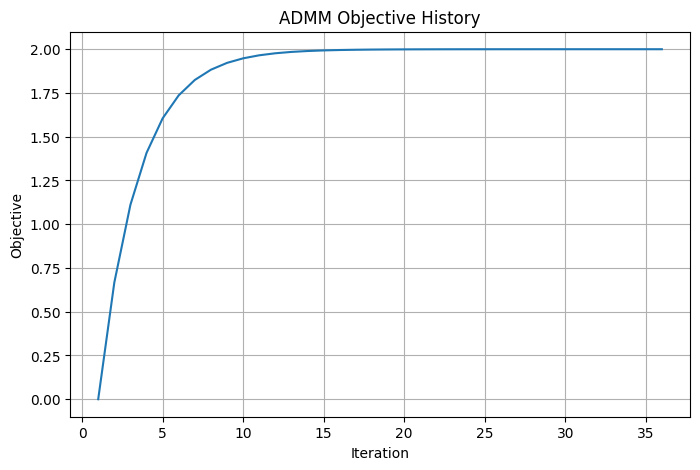

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(solver.objective_history_) + 1),
    solver.objective_history_
)

plt.xlabel("Iteration")
plt.ylabel("Objective")
plt.title("ADMM Objective History")
plt.grid(True)

plt.show()

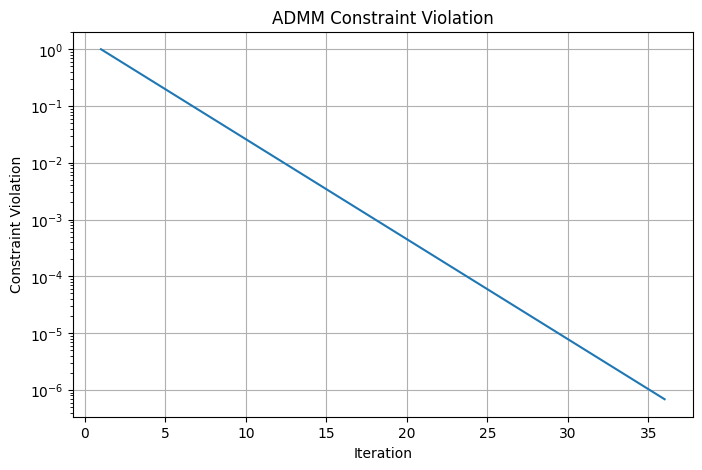

In [15]:
plt.figure(figsize=(8, 5))

plt.semilogy(
    range(1, len(solver.constraint_violation_history_) + 1),
    np.maximum(
        solver.constraint_violation_history_,
        1e-16
    )
)

plt.xlabel("Iteration")
plt.ylabel("Constraint Violation")
plt.title("ADMM Constraint Violation")
plt.grid(True)

plt.show()

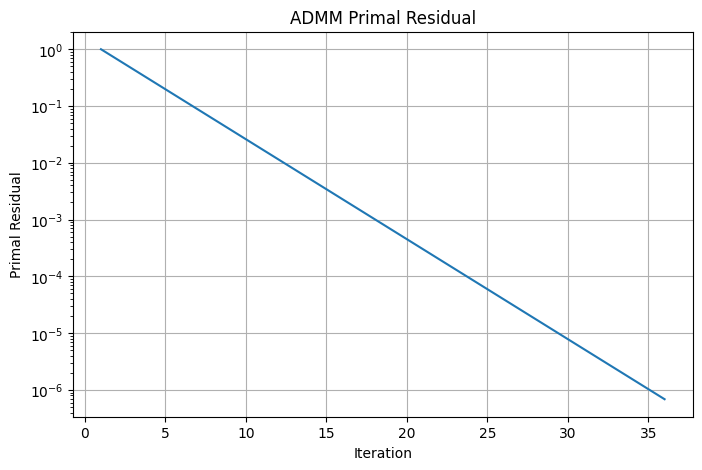

In [16]:
plt.figure(figsize=(8, 5))

plt.semilogy(
    range(1, len(solver.primal_residual_history_) + 1),
    np.maximum(
        solver.primal_residual_history_,
        1e-16
    )
)

plt.xlabel("Iteration")
plt.ylabel("Primal Residual")
plt.title("ADMM Primal Residual")
plt.grid(True)

plt.show()

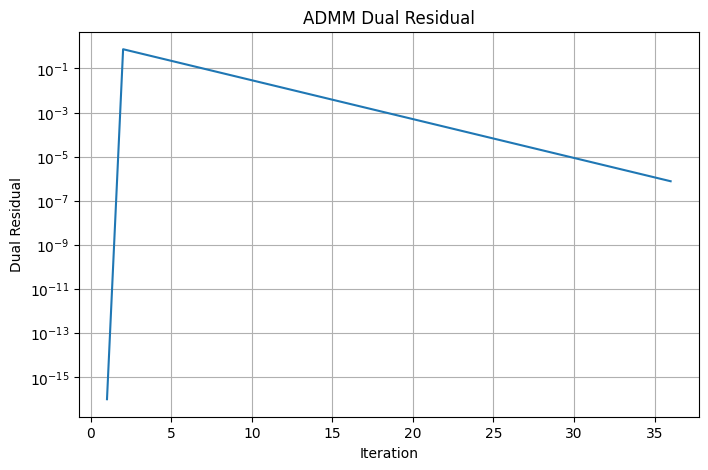

In [17]:
plt.figure(figsize=(8, 5))

plt.semilogy(
    range(1, len(solver.dual_residual_history_) + 1),
    np.maximum(
        solver.dual_residual_history_,
        1e-16
    )
)

plt.xlabel("Iteration")
plt.ylabel("Dual Residual")
plt.title("ADMM Dual Residual")
plt.grid(True)

plt.show()

In [18]:
rho_values = [
    0.1,
    0.5,
    1.0,
    2.0,
    5.0
]

rho_results = []

for rho in rho_values:

    test_solver = ADMMSolver(
        rho=rho,
        max_iterations=1000,
        tolerance=1e-6,
        backend="CPU"
    )

    test_result = test_solver.solve(model)

    rho_results.append({
        "rho": rho,
        "status": test_result.status,
        "iterations": test_result.iterations,
        "objective": test_result.objective,
        "constraint_violation": test_result.constraint_violation,
        "solve_time": test_result.solve_time
    })


print("Rho Experiment")
print("=" * 80)

for row in rho_results:
    print(row)

Rho Experiment
{'rho': 0.1, 'status': 'CONVERGED', 'iterations': 197, 'objective': 1.9999981123633694, 'constraint_violation': 9.438183152798985e-07, 'solve_time': 0.061500699957832694}
{'rho': 0.5, 'status': 'CONVERGED', 'iterations': 57, 'objective': 1.9999982058754981, 'constraint_violation': 8.970622509263393e-07, 'solve_time': 0.012462900020182133}
{'rho': 1.0, 'status': 'CONVERGED', 'iterations': 36, 'objective': 1.9999986264770233, 'constraint_violation': 6.867614883443451e-07, 'solve_time': 0.009766299976035953}
{'rho': 2.0, 'status': 'CONVERGED', 'iterations': 24, 'objective': 1.999998114593327, 'constraint_violation': 9.42703336503925e-07, 'solve_time': 0.004574600141495466}
{'rho': 5.0, 'status': 'CONVERGED', 'iterations': 19, 'objective': 1.9999996346757518, 'constraint_violation': 1.8266212409301374e-07, 'solve_time': 0.004914799937978387}


In [19]:
print(
    f"{'rho':<10}"
    f"{'status':<25}"
    f"{'iterations':<15}"
    f"{'objective':<15}"
    f"{'violation':<15}"
    f"{'time':<12}"
)

print("-" * 90)

for row in rho_results:

    print(
        f"{row['rho']:<10}"
        f"{row['status']:<25}"
        f"{row['iterations']:<15}"
        f"{row['objective']:<15.6f}"
        f"{row['constraint_violation']:<15.6e}"
        f"{row['solve_time']:<12.6f}"
    )

rho       status                   iterations     objective      violation      time        
------------------------------------------------------------------------------------------
0.1       CONVERGED                197            1.999998       9.438183e-07   0.061501    
0.5       CONVERGED                57             1.999998       8.970623e-07   0.012463    
1.0       CONVERGED                36             1.999999       6.867615e-07   0.009766    
2.0       CONVERGED                24             1.999998       9.427033e-07   0.004575    
5.0       CONVERGED                19             2.000000       1.826621e-07   0.004915    


In [20]:
max_model = OptimizationModel(
    A=A_test,
    constraint_lower=constraint_lower_test,
    constraint_upper=constraint_upper_test,
    objective=c_test,
    variable_lower=variable_lower_test,
    variable_upper=variable_upper_test,
    variable_integrality=variable_integrality_test,
    objective_sense="max"
)

print(max_model.summary())

{'problem_type': 'LP', 'variables': 2, 'constraints': 2, 'nonzeros': 4, 'integer_variables': 0, 'continuous_variables': 2, 'objective_sense': 'max'}


In [21]:
max_solver = ADMMSolver(
    rho=1.0,
    max_iterations=1000,
    tolerance=1e-6,
    backend="CPU"
)

max_result = max_solver.solve(max_model)

print("MAX Problem")
print("=" * 50)

print("Status:", max_result.status)
print("Objective:", max_result.objective)
print("Solution:", max_result.solution)
print("Constraint violation:", max_result.constraint_violation)
print("Bound violation:", max_result.bound_violation)
print("Iterations:", max_result.iterations)

MAX Problem
Status: CONVERGED
Objective: 2.333333333333333
Solution: [0.33333333 0.66666667]
Constraint violation: 0.0
Bound violation: 0.0
Iterations: 1


In [22]:
max_check = check_solution(
    max_model,
    max_result.solution
)

print("MAX Solution Verification")
print("=" * 50)

for key, value in max_check.items():
    print(f"{key}: {value}")

MAX Solution Verification
objective: 2.333333333333333
constraint_violation: 0.0
bound_violation: 0.0
integrality_violation: 0.0


In [23]:
print("FINAL CHECKS")
print("=" * 60)

# 1. Generic model
assert isinstance(model, OptimizationModel)
print("✓ OptimizationModel is being used")

# 2. Sparse matrix
assert sp.issparse(model.A)
print("✓ Constraint matrix is sparse")

# 3. Correct problem type
assert model.problem_type == "LP"
print("✓ Problem identified as LP")

# 4. Solver result
assert isinstance(result, OptimizationResult)
print("✓ Solver returns OptimizationResult")

# 5. Solution size
assert len(result.solution) == model.n_variables
print("✓ Solution dimension is correct")

# 6. Bound feasibility
assert result.bound_violation <= 1e-5
print("✓ Variable bounds satisfied")

# 7. Constraint feasibility
assert result.constraint_violation <= 1e-5
print("✓ Constraint violation is within tolerance")

# 8. Objective agreement
objective_difference = abs(
    result.objective - highs_result.fun
)

print(
    "Objective difference from HiGHS:",
    objective_difference
)

print()
print("ALL BASIC CHECKS PASSED")

FINAL CHECKS
✓ OptimizationModel is being used
✓ Constraint matrix is sparse
✓ Problem identified as LP
✓ Solver returns OptimizationResult
✓ Solution dimension is correct
✓ Variable bounds satisfied
✓ Constraint violation is within tolerance
Objective difference from HiGHS: 1.3735229766886903e-06

ALL BASIC CHECKS PASSED


In [24]:
print("=" * 60)
print("ADMM SOLVER SUMMARY")
print("=" * 60)

print("Architecture:")
print("OptimizationModel -> ADMMSolver -> OptimizationResult")

print()
print("Problem type:", model.problem_type)
print("Variables:", model.n_variables)
print("Constraints:", model.n_constraints)
print("Nonzeros:", model.nnz)

print()
print("ADMM status:", result.status)
print("ADMM objective:", result.objective)
print("ADMM iterations:", result.iterations)
print("ADMM solve time:", result.solve_time)
print("Constraint violation:", result.constraint_violation)
print("Bound violation:", result.bound_violation)

print()
print("HiGHS objective:", highs_result.fun)
print(
    "Objective difference:",
    abs(result.objective - highs_result.fun)
)

print()
print("Backend:", result.backend)

ADMM SOLVER SUMMARY
Architecture:
OptimizationModel -> ADMMSolver -> OptimizationResult

Problem type: LP
Variables: 2
Constraints: 2
Nonzeros: 4

ADMM status: CONVERGED
ADMM objective: 1.9999986264770233
ADMM iterations: 36
ADMM solve time: 0.012298200046643615
Constraint violation: 6.867614883443451e-07
Bound violation: 0.0

HiGHS objective: 2.0
Objective difference: 1.3735229766886903e-06

Backend: CPU
